<a href="https://colab.research.google.com/github/alyssaiapalucci4/colab-git-assignment2-AI/blob/main/Lesson_6_ml_basic_assignment_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Assignment 6: House Price Prediction Using California Housing Data
#### Name: Alyssa Iapalucci

#### Submission Links:

#### Google Colab: https://colab.research.google.com/drive/17f1ajdKUod1mgfxWKfCGIHT8ZHr09qj6?usp=sharing

#### GitHub: https://github.com/alyssaiapalucci4/colab-git-assignment2-AI

In [1]:
# Importing required libraries for data analysis, visualization, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Data Collection and Loading

housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
# Quick Check of Data

print(df.head())
print(df.info())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population


Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


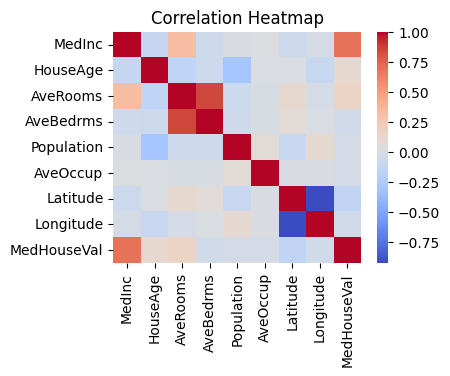

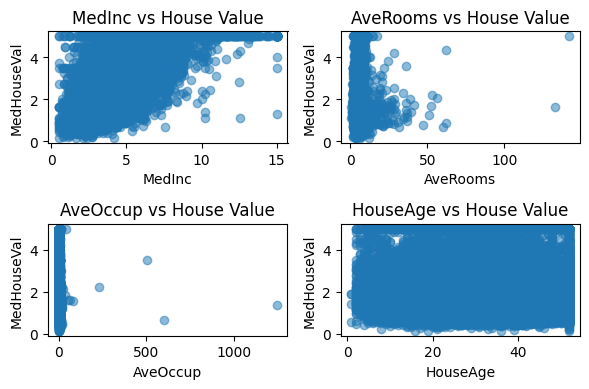

In [4]:
# EDA and Data Preprocessing

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Correlation heatmap (IMPORTANT for full marks)
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


# Scatter plots in ONE figure (fixes scrolling issue)
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']

fig, axes = plt.subplots(2, 2, figsize=(6,4))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['MedHouseVal'], alpha=0.5)
    axes[i].set_title(f"{feature} vs House Value")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()

In [5]:
# ML Model Training

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# Model Evaluation

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("RMSE:", rmse)
print("R2 Score:", r2)


# Small interpretation (IMPORTANT for 4/4 insight)
print("\nInsight:")
print("Higher MedInc strongly increases house value.")
print("Model explains a moderate amount of variance in prices.")


Model Evaluation:
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508

Insight:
Higher MedInc strongly increases house value.
Model explains a moderate amount of variance in prices.


In [7]:
# Model Prediction

# Must match feature order in X
new_data = np.array([[3, 30, 6, 3, 34, -118, 1, 1500]])

prediction = model.predict(new_data)

print("\nPrediction for new data:", prediction[0])


Prediction for new data: -684.3418839463053


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
